# 1. Introduction to the Real-World Problem

# Wisconsin Breast Cancer Dataset

Este Dataset tiene aplicación médica, enfocada en el diágnostico de cáncer de mama.
Entre las variables predictivas se encuentran: el radio, la textura, perímetro, área, entre otros (10 features). Se calcula la media, la desviación estándar y "peor" (media de los 3 valores más grandes) de cada feature, dando un total de 30.
La variable objetivo es Diagnosis (Maligno y Benigno).

# Data Cleaning

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset (Añadiendo los títulos de las columnas, proveniente de la documentación del dataset)
column_names = ['id', 'diagnosis', 'mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension']

df = pd.read_csv('wdbc.data', names=column_names)

# Limpieza de la columna ID (irrelevante) y mapeo de la columna 'diagnosis' para convertirla en valores numéricos
df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Validación de datos y manejo de valores faltantes
# Conteo por columna y suma de todas las columnas.
if df.isnull().sum().sum():
    print("Existen valores faltantes en el dataset.")
else:
    print("No existen valores faltantes en el dataset.")

No existen valores faltantes en el dataset.


In [42]:
df

,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


# Exploratory Data Analysis

In [43]:
df.describe()

,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Las escalas de los datos son muy distintas, lo que podría llegar a ocasionar que se asignen valores de relevancia de manera errónea.

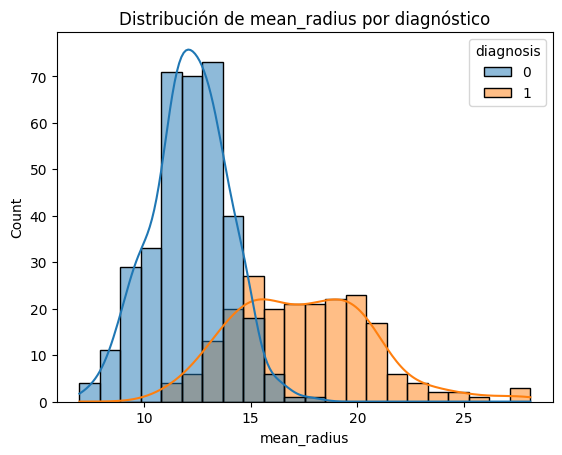

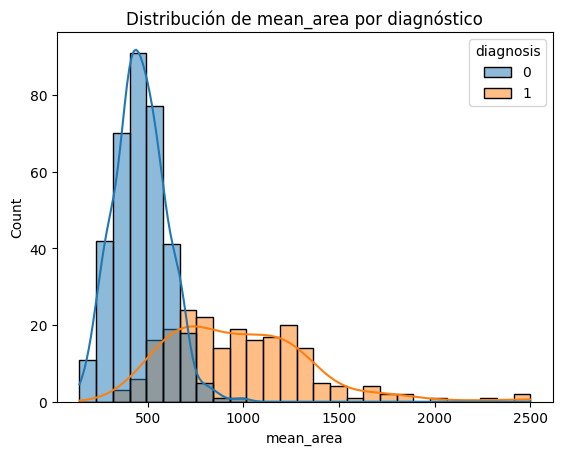

In [44]:
# Histograma de las variables 'mean_radius' y 'mean_area' para observar su distribución
sns.histplot(data = df, x='mean_radius', hue='diagnosis', kde=True)
plt.title('Distribución de mean_radius por diagnóstico')
plt.show()

sns.histplot(data = df, x='mean_area', hue='diagnosis', kde=True)
plt.title('Distribución de mean_area por diagnóstico')
plt.show()

Las celúlas cancerígenas muestran una tendencia a tener núcleos más grandes, esto puede indicar un alto valor predictivo de estas variables.

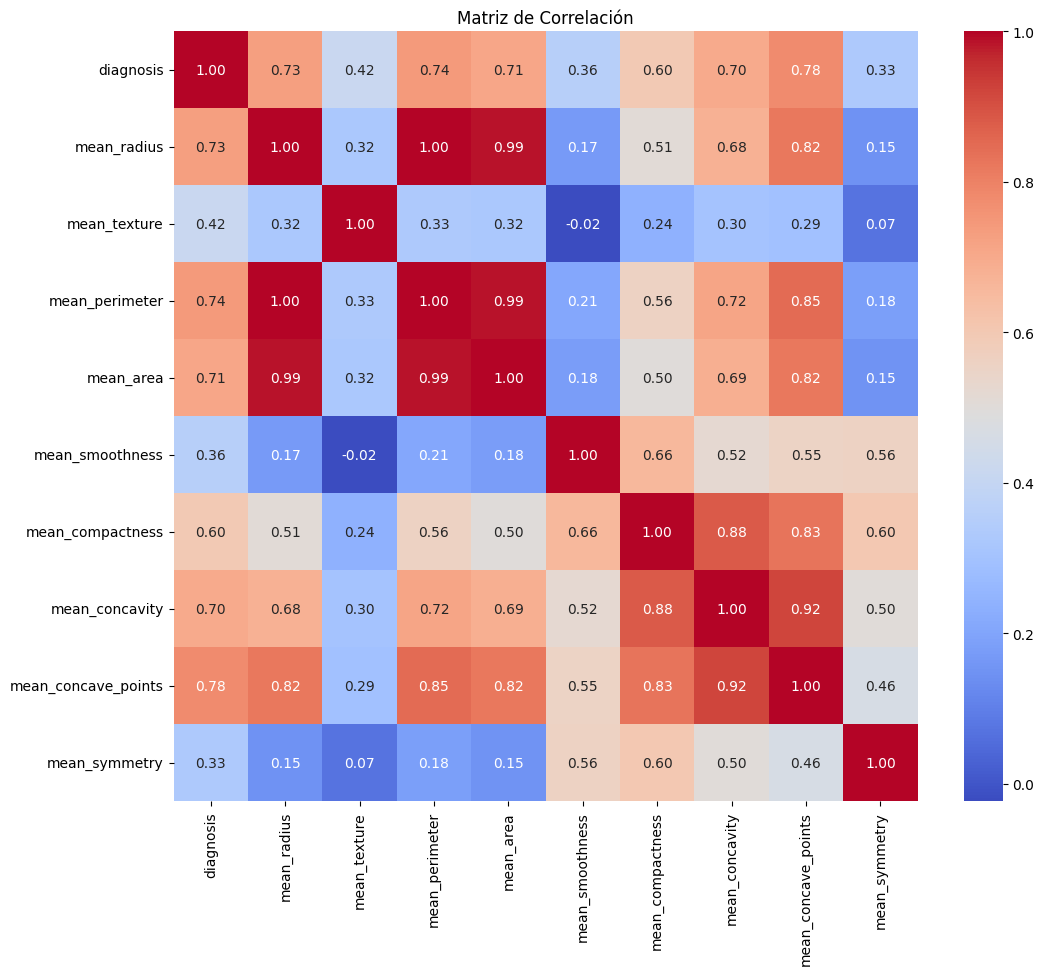

In [45]:
# Análisis de correlación entre las variables para identificar posibles relaciones
correlation_matrix = df.iloc[:, 0:10].corr() # Primeros 10 valores para claridad
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

Las variables geométricas muestran una alta correlación entre ellas, al ser variables colineales puede ser beneficioso utilizar alguna técnica para reducir la dimensionalidad. Al ser variables geométricas, podría servir obtener una variable derivada que las represente a todas.

Igualmente, es posible notar la alta relación entre compactness, concavity y concave_points, por lo que este sería el segundo grupo de variables que muestran muticolinealidad.

Todas las features de estos grupos muestran una correlación de al menos .7, exceptuando "mean_concavity" con .6, con el diagnóstico. Mostrando un posible alto valor predictivo de estas variables.

# 2. Design and Training of the Single-Neuron Model


In [6]:
# Importar librerías para la construcción del modelo de red neuronal
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model


In [46]:
# Global seed para reproducibilidad
tf.random.set_seed(4500)

# Preparación de los datos para el modelo
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# Estandarización de las características para mejorar el rendimiento del modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
# Architectura de la red neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Compilación del modelo con el optimizador Adam y la función de pérdida de entropía cruzada binaria

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [51]:
# Hiperparámetros para el entrenamiento
EPOCHS = 100
LEARNING_RATE = 0.001
BATCH_SIZE = 32
VALIDATION_RATIO = 0.2


# 3. Learning Curve Analysis


In [52]:
# Evaluación del modelo antes del entrenamiento
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2544 - loss: 1.1667  
Test Accuracy: 0.2544


In [53]:
# Entrenamiento del modelo con validación
history = model.fit(X_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALIDATION_RATIO)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3159 - loss: 1.0307 - val_accuracy: 0.3736 - val_loss: 0.9370
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3599 - loss: 0.9387 - val_accuracy: 0.4286 - val_loss: 0.8492
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4286 - loss: 0.8552 - val_accuracy: 0.4835 - val_loss: 0.7708
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4918 - loss: 0.7804 - val_accuracy: 0.5714 - val_loss: 0.7021
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5659 - loss: 0.7141 - val_accuracy: 0.6044 - val_loss: 0.6430
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6374 - loss: 0.6559 - val_accuracy: 0.6264 - val_loss: 0.5927
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7033 - loss: 0.6050 - val_accuracy: 0.7033 - val_loss: 0.5498
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 0.5605 - val_accuracy: 0.7473 - v

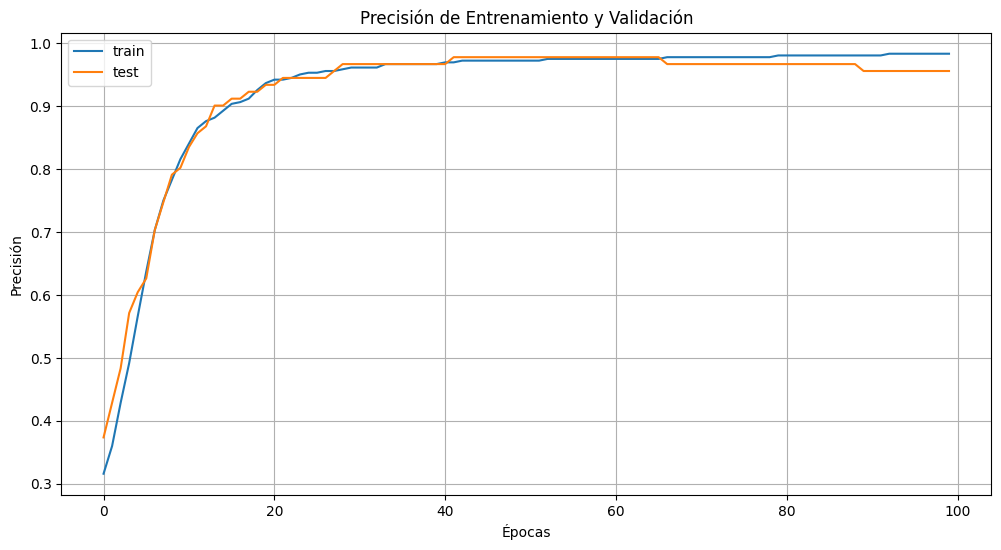

In [54]:
# Gráfica de precisión de entrenamiento y validación a lo largo de las épocas
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(['train', 'test'])
plt.grid()

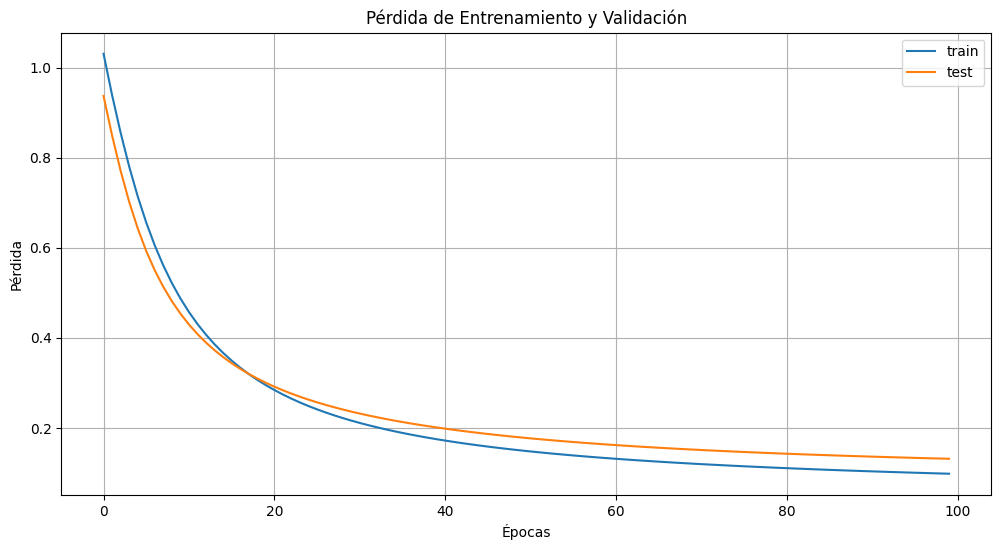

In [55]:
# Gráfica de pérdida de entrenamiento y validación a lo largo de las épocas
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(['train', 'test'])
plt.grid()

*INTERPRETACIÓN*

# 4. Model Evaluation and Testing Data

In [56]:
#Predecir (probabilidades) y convertir a clases (0 o 1)
y_prob = model.predict(X_test_scaled)          # probabilidad de clase 1
y_pred = (y_prob >= 0.5).astype(int).ravel()   # umbral 0.5 -> clase

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step



Confusion matrix:
 [[71  0]
 [ 2 41]]


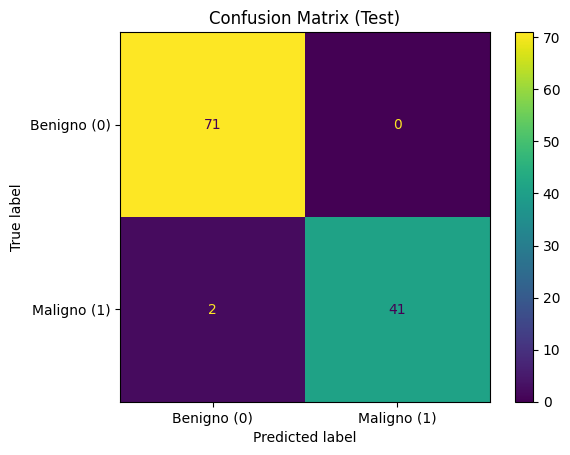

In [57]:
#Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(cm, display_labels=["Benigno (0)", "Maligno (1)"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()

La matriz de confusión muestra que el modelo clasificó correctamente 71 casos benignos y 42 malignos, con solo dos errores, donde un tumor maligno fue clasificado como benigno. Esto indica un desempeño muy alto del modelo en el conjunto de prueba.

In [58]:
#Métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP)

print("\nPrecision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(f1, 4))


Precision: 1.0
Recall: 0.9535
Specificity: 1.0
F1-score: 0.9762


##Interpretación de las métricas


*   La precision = 1.0 indica que todos los casos que el modelo clasificó como malignos realmente lo eran. Esto significa que el modelo no generó falsos positivos, es decir, ningún tumor benigno fue clasificado incorrectamente como maligno.

*   El recall = 0.9535 mide la capacidad del modelo para identificar correctamente los casos malignos. Este valor indica que el modelo detecta aproximadamente el 95.4% de los tumores malignos, lo que significa que solo un caso maligno fue clasificado incorrectamente como benigno (falso negativo).

* La specificity = 1.0 indica que todos los tumores benignos fueron correctamente clasificados como benignos. Esto muestra que el modelo tiene una excelente capacidad para distinguir los casos no cancerígenos.

* El F1-score = 0.9762 combina precision y recall en una sola métrica, proporcionando una medida del equilibrio entre ambas. Un valor cercano a 1 indica que el modelo tiene un muy buen rendimiento general en la clasificación.

En el contexto del diagnóstico de cáncer de mama, la métrica más importante es recall (sensibilidad), ya que un falso negativo implicaría que un tumor maligno no sea detectado, lo que podría retrasar el tratamiento del paciente. Por lo tanto, es fundamental que el modelo identifique correctamente la mayor cantidad posible de casos malignos.

En general, el modelo presenta un desempeño muy alto, con métricas cercanas a 1 y solo dos errores de clasificación en el conjunto de prueba. Esto indica que el modelo tiene una muy buena capacidad para diferenciar entre tumores benignos y malignos, por lo que su rendimiento puede considerarse muy adecuado para este problema de clasificación.



# 5. Save the Model

In [59]:
# Guardar el modelo entrenado
model.save("breast_cancer_model.keras")

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [60]:
# Cargar el modelo guardado
loaded_model = load_model("breast_cancer_model.keras")

print("Modelo cargado correctamente")

Modelo cargado correctamente


In [63]:
loss, accuracy = loaded_model.evaluate(X_test_scaled, y_test)

print("Accuracy del modelo cargado:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9825 - loss: 0.0961 
Accuracy del modelo cargado: 0.9824561476707458


Guardar un modelo entrenado permite reutilizarlo sin tener que volver a entrenarlo, lo que ahorra tiempo y recursos computacionales. Además, facilita su implementación en aplicaciones reales y permite compartirlo o reproducir los resultados en otros sistemas.

# 6. Apply PCA to the Original Dataset

In [64]:
# Cargar el dataset para PCA
dfPCA = pd.read_csv('wdbc.data', names=column_names)

# Limpieza de la columna ID (irrelevante) y mapeo de la columna 'diagnosis' para convertirla en valores numéricos
dfPCA = dfPCA.drop(columns=['id'])
dfPCA['diagnosis'] = dfPCA['diagnosis'].map({'M': 1, 'B': 0})

In [67]:
# Estandarización de las características para PCA
XPCA = dfPCA.drop(columns=['diagnosis'])
yPCA = dfPCA['diagnosis']
XPCA_scaled = StandardScaler().fit_transform(XPCA)

# Matriz de covarianza
cov_matrix = np.cov(XPCA_scaled, rowvar=False)

cov_df = pd.DataFrame(cov_matrix, index=XPCA.columns, columns=XPCA.columns)

In [68]:
# Eigenvalores y eigenvectores
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalores:\n", eigenvalues)

Eigenvalores:
 [1.33049908e+01 5.70137460e+00 2.82291016e+00 1.98412752e+00
 1.65163324e+00 1.20948224e+00 6.76408882e-01 4.77456255e-01
 4.17628782e-01 3.51310875e-01 2.94433153e-01 2.61621161e-01
 2.41782421e-01 1.57286149e-01 9.43006956e-02 8.00034045e-02
 5.95036135e-02 5.27114222e-02 4.95647002e-02 1.33279057e-04
 7.50121413e-04 1.59213600e-03 6.91261258e-03 8.19203712e-03
 1.55085271e-02 1.80867940e-02 2.43836914e-02 2.74877113e-02
 3.12142606e-02 3.00256631e-02]


In [ ]:
# Varianza explicada en porcentaje
explained_variance = eigenvalues / np.sum(eigenvalues) * 100
accumulated_variance = 0

# Hasta alcanzar 95% de la varianza explicada
for i, val in enumerate(explained_variance):
    if accumulated_variance < 95:
        accumulated_variance = np.sum(explained_variance[:i+1])
        print(f"Componente {i+1}: {val:.2f}% de la varianza explicada, Varianza explicada: {accumulated_variance:.2f}%") 
        k = i + 1


Componente 1: 44.27% de la varianza explicada, Varianza explicada: 44.27%
Componente 2: 18.97% de la varianza explicada, Varianza explicada: 63.24%
Componente 3: 9.39% de la varianza explicada, Varianza explicada: 72.64%
Componente 4: 6.60% de la varianza explicada, Varianza explicada: 79.24%
Componente 5: 5.50% de la varianza explicada, Varianza explicada: 84.73%
Componente 6: 4.02% de la varianza explicada, Varianza explicada: 88.76%
Componente 7: 2.25% de la varianza explicada, Varianza explicada: 91.01%
Componente 8: 1.59% de la varianza explicada, Varianza explicada: 92.60%
Componente 9: 1.39% de la varianza explicada, Varianza explicada: 93.99%
Componente 10: 1.17% de la varianza explicada, Varianza explicada: 95.16%


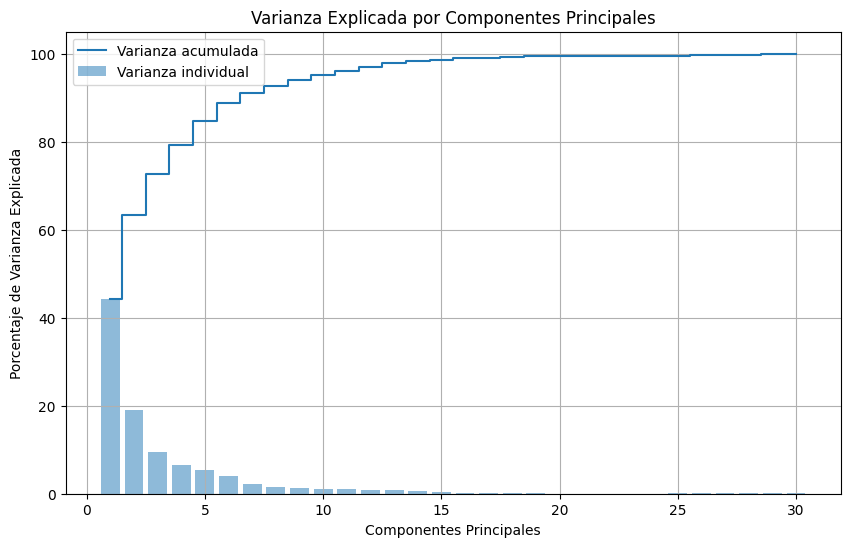

In [73]:
# explained variance ratio plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Varianza individual')
plt.step(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), where='mid', label='Varianza acumulada')
plt.xlabel('Componentes Principales')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.title('Varianza Explicada por Componentes Principales')
plt.legend()
plt.grid()

*INTERPRETACIÓN*

# 7. Train a New Single-Neuron Model Using PCA Features

# 8. Performance Comparison

# 9. Personal Conclusions

Carlos.

https://github.com/Carlos-HC/Single-Neuron-Network-Team9

# 10. References